## **Business Problem**

Energy utility companies face significant revenue loss due to customer churn. 
The objective of this analysis is to explore customer consumption patterns, 
pricing behavior, and service characteristics to identify key factors 
associated with customer churn.

The insights derived from this exploratory analysis will guide feature 
engineering and predictive modeling for churn prediction.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# shows plots in jupyter notebook
%matplotlib inline

#set plot style
sns.set(color_codes=True)

## **Dataset Overview**

This project uses two datasets provided by an energy utility company to analyze customer behavior and predict customer churn.

#### 1. Client Dataset (`client_data.csv`)
The client dataset contains customer-level information including electricity and gas consumption, contract details, pricing forecasts, and churn status.

#### 2. Price Dataset (`price_data.csv`)
The price dataset contains historical electricity pricing information across different pricing periods (off-peak, peak, and mid-peak). This dataset helps analyze how price variations influence customer churn behavior.

In [4]:
#Data Loading
client=pd.read_csv(r"C:\Users\hanan\Downloads\client_data (1).csv")
price=pd.read_csv(r"C:\Users\hanan\Downloads\price_data (1).csv")

## **Client Dataset Exploration**

### Client Dataset Features

| Feature | Description |
|--------|-------------|
| id | Unique identifier for each client |
| activity_new | Category of the company's activity |
| channel_sales | Code representing the sales channel |
| cons_12m | Electricity consumption over the past 12 months |
| cons_gas_12m | Gas consumption over the past 12 months |
| cons_last_month | Electricity consumption during the last month |
| date_activ | Date of contract activation |
| date_end | Registered contract end date |
| date_modif_prod | Date of the last modification of the product |
| date_renewal | Date of the next contract renewal |
| forecast_cons_12m | Forecasted electricity consumption for the next 12 months |
| forecast_cons_year | Forecasted electricity consumption for the next calendar year |
| forecast_discount_energy | Forecasted value of current energy discount |
| forecast_meter_rent_12m | Forecasted meter rental bill for the next 12 months |
| forecast_price_energy_off_peak | Forecasted energy price for off-peak period |
| forecast_price_energy_peak | Forecasted energy price for peak period |
| forecast_price_pow_off_peak | Forecasted power price for off-peak period |
| has_gas | Indicates whether the client is also a gas customer |
| imp_cons | Current paid consumption |
| margin_gross_pow_ele | Gross margin on power subscription |
| margin_net_pow_ele | Net margin on power subscription |
| nb_prod_act | Number of active products and services |
| net_margin | Total net margin generated by the client |
| num_years_antig | Number of years the client has been with the company |
| origin_up | Code of the electricity campaign the client first subscribed to |
| pow_max | Subscribed maximum power |
| churn | Target variable indicating whether the client churned in the next 3 months |

In [5]:
client.head(2)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0


## **Data Quality Assessment**

In [6]:
client.shape

#Data Type Consistency Check
client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [7]:
#missing values check
client.isnull().sum()

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64

In [8]:
# Duplicate Records check
client.duplicated().sum()

0

## **Dataset Churn Distribution**

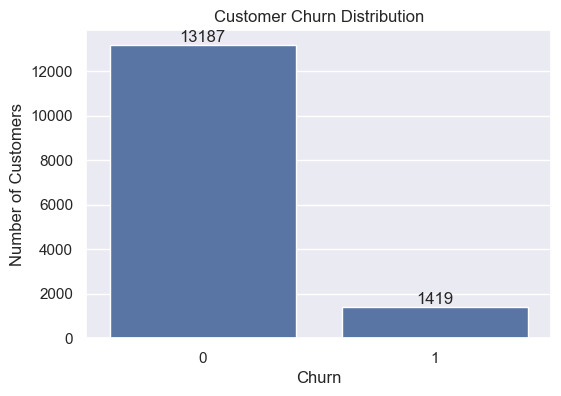

In [9]:
# Churn Distribution based on energy

plt.figure(figsize=(6,4))
ax = sns.countplot(x="churn", data=client)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
    
plt.show()

The dataset exhibits a pronounced class imbalance, with 13,187 customers (~90%) retained and 1,419 customers (~10%) churned. This distribution is consistent with real-world business scenarios, where churn events are relatively infrequent but carry significant revenue impact. This imbalance will be addressed during model training using class weighting techniques.

> Churn prediction will be treated as a cost-sensitive classification problem, where false negatives are more expensive than false positives.

## **Energy Consumption v/s churn**

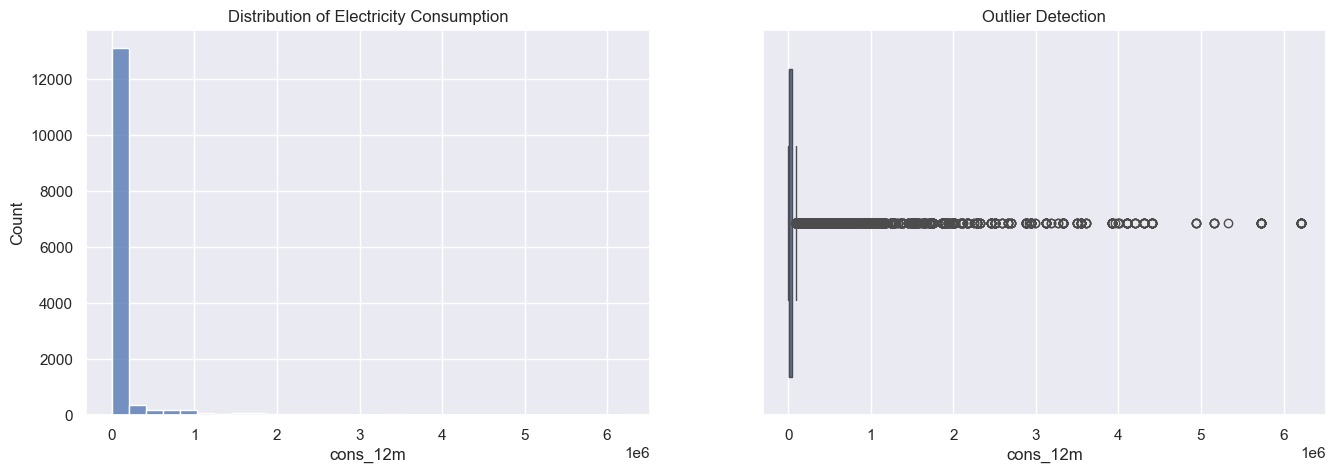

Number of outliers: 2084
percentage of outliers: 14.268108996302889


In [10]:
#Outlier Detection For Electricity Consumption

fig, axes = plt.subplots(1,2, figsize=(16,5))

# Histogram Visualization 
sns.histplot(client["cons_12m"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Electricity Consumption")

# Boxplot Visualization
sns.boxplot(x=client["cons_12m"], ax=axes[1])
axes[1].set_title("Outlier Detection")

plt.show()

# Calculate IQR
Q1 = client["cons_12m"].quantile(0.25)
Q3 = client["cons_12m"].quantile(0.75)

IQR = Q3 - Q1

min = Q1 - 1.5 * IQR
max = Q3 + 1.5 * IQR

outliers = client[
    (client["cons_12m"] < min) |
    (client["cons_12m"] > max)
]

#No of outliers
print("Number of outliers:", len(outliers))

#Percentage of outliers
print("percentage of outliers:", (len(outliers)/len(client))*100)

The distribution of electricity consumption (`cons_12m`) was analyzed to identify potential outliers.

- The distribution is highly right-skewed, with most customers having low consumption and a small number exhibiting extremely high usage.
- Boxplot analysis revealed a large number of points beyond the upper whisker, indicating the presence of significant outliers.
- Total outliers detected: **2,084**
- Percentage of outliers: **~14.27%**
- These outliers can disproportionately influence statistical measures and machine learning models.
- The relatively high proportion of outliers suggests that these values are not merely noise, but may represent distinct customer segments such as high-consumption or industrial users.

>**Given their potential business significance, outliers should not be removed blindly.**  Instead, transformations (e.g., log scaling) or segmentation approaches should be used to handle them appropriately.

## **Energy Consumption Last Month v/s Churn**

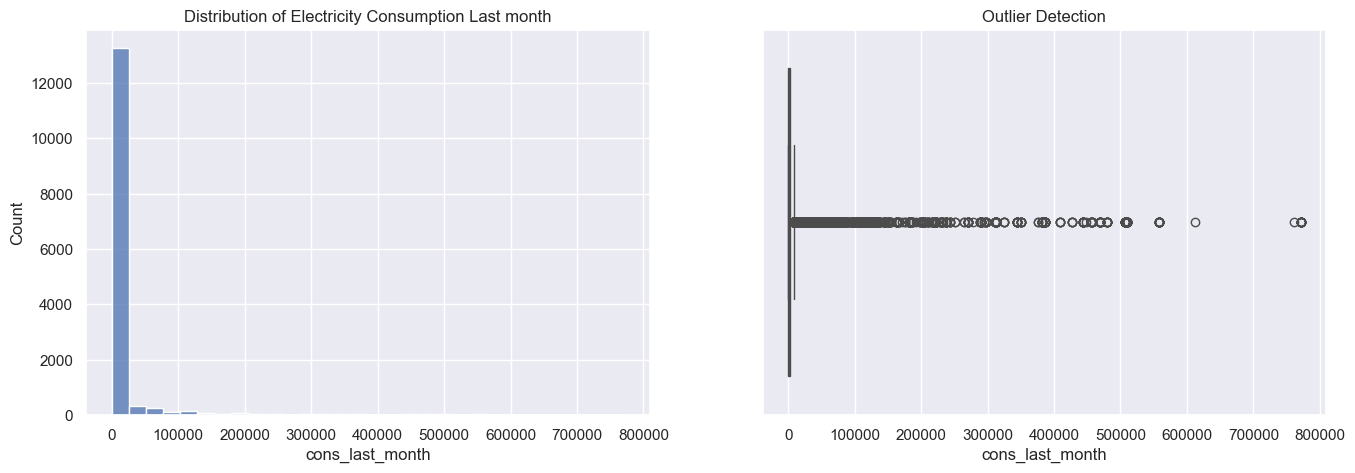

Number of outliers: 2051
percentage of outliers: 14.042174448856635


In [13]:
#Outlier Detection For Electricity Consumption

fig, axes = plt.subplots(1,2, figsize=(16,5))

# Histogram Visualization 
sns.histplot(client["cons_last_month"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Electricity Consumption Last month")

# Boxplot Visualization
sns.boxplot(x=client["cons_last_month"], ax=axes[1])
axes[1].set_title("Outlier Detection")

plt.show()

# Calculate IQR
Q1 = client["cons_last_month"].quantile(0.25)
Q3 = client["cons_last_month"].quantile(0.75)

IQR = Q3 - Q1

min = Q1 - 1.5 * IQR
max = Q3 + 1.5 * IQR

outliers = client[
    (client["cons_last_month"] < min) |
    (client["cons_last_month"] > max)
]

#No of outliers
print("Number of outliers:", len(outliers))

#Percentage of outliers
print("percentage of outliers:", (len(outliers)/len(client))*100)

## **Long term & Short term Energy Consumption v/s Churn Analysis**

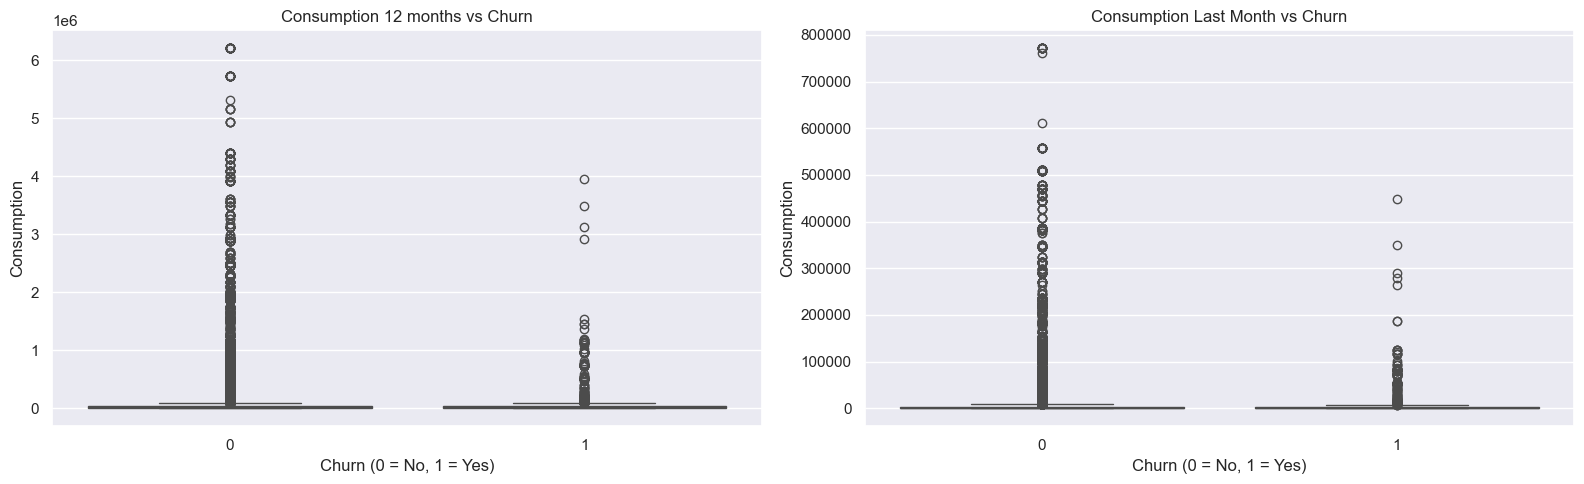

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# 12 months consumption
sns.boxplot(x="churn", y="cons_12m", data=client, ax=axes[0])
axes[0].set_title("Consumption 12 months vs Churn")
axes[0].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[0].set_ylabel("Consumption")

# Last month consumption
sns.boxplot(x="churn", y="cons_last_month", data=client, ax=axes[1])
axes[1].set_title("Consumption Last Month vs Churn")
axes[1].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[1].set_ylabel("Consumption")

plt.tight_layout()
plt.show()

- Both 12-month and last-month consumption distributions are **highly right-skewed**, with a large number of extreme outliers.
- Most customers have very low consumption values, while a small number exhibit extremely high usage.
- No clear separation between churned and non-churned customers is visible in the raw consumption values.

**Insights:**
- Raw consumption features (`cons_12m`, `cons_last_month`) are heavily influenced by outliers, which may mask underlying patterns.
- The lack of visible separation suggests that these features, in their raw form, may have **limited predictive power**.

**Conclusion:**
> Raw consumption variables are not directly useful for distinguishing churn behavior due to skewness and extreme outliers.

**Next Steps:**
- Apply **log transformation** to reduce skewness and stabilize variance.
- Engineer behavioral features such as:
  - Consumption change (`cons_change`)
  - Consumption ratio (`cons_ratio`)
- Re-evaluate their relationship with churn after transformation.

## **Max allowed capacity**

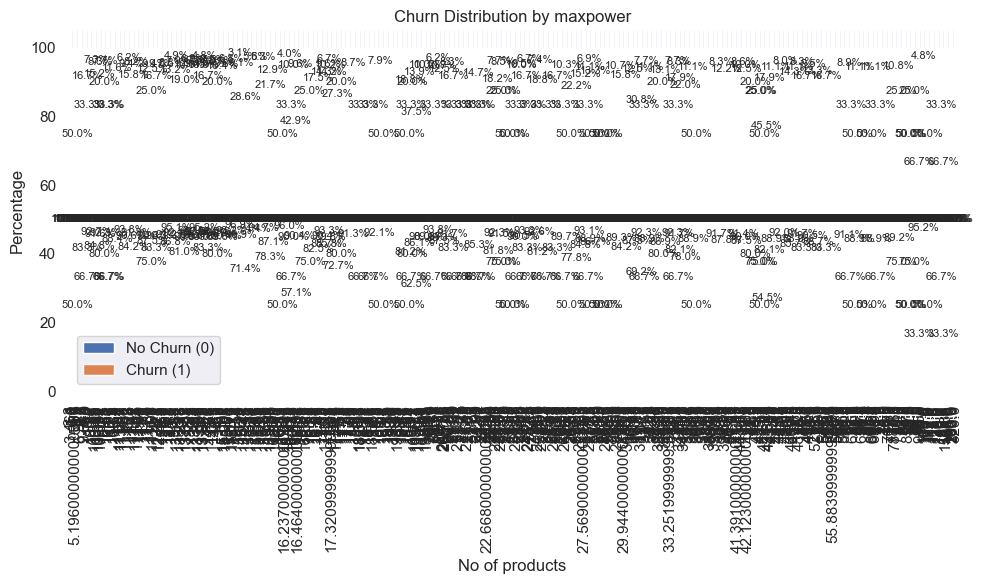

In [68]:
# Create aggregation table
maxpower = (client.groupby(['pow_max', 'churn']).size().unstack(fill_value=0))

# Total customers per channel ( total = churn + no churn )
maxpower_count = maxpower.sum(axis=1)

# Counts to percentage ( nochurn% = nochurn/total )
maxpower_churn = maxpower.div(maxpower_count, axis=0) * 100

# Plot maxpower
ax = maxpower_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6))

# Annotate each segment
for i, (index, row) in enumerate(maxpower_churn.iterrows()):
    cumulative = 0
    for val in row:
        if val > 0:
            ax.text(
                i,
                cumulative + val / 2, f"{val:.1f}%",
                ha='center', va='center', fontsize=8)
            cumulative += val
                
plt.title("Churn Distribution by maxpower")
plt.xlabel("No of products")
plt.ylabel("Percentage")
plt.legend(["No Churn (0)", "Churn (1)"])
plt.tight_layout()
plt.show()

## **Gas Consumption v/s Churn**

In [18]:
print(client["has_gas"].unique())

['t' 'f']


In [19]:
client["has_gas"] = client["has_gas"].map({"t": True, "f": False})
client = client.copy()

# Split the gas users
gas_clients = client[client["has_gas"] == True].copy()
non_gas_clients = client[client["has_gas"] == False].copy()


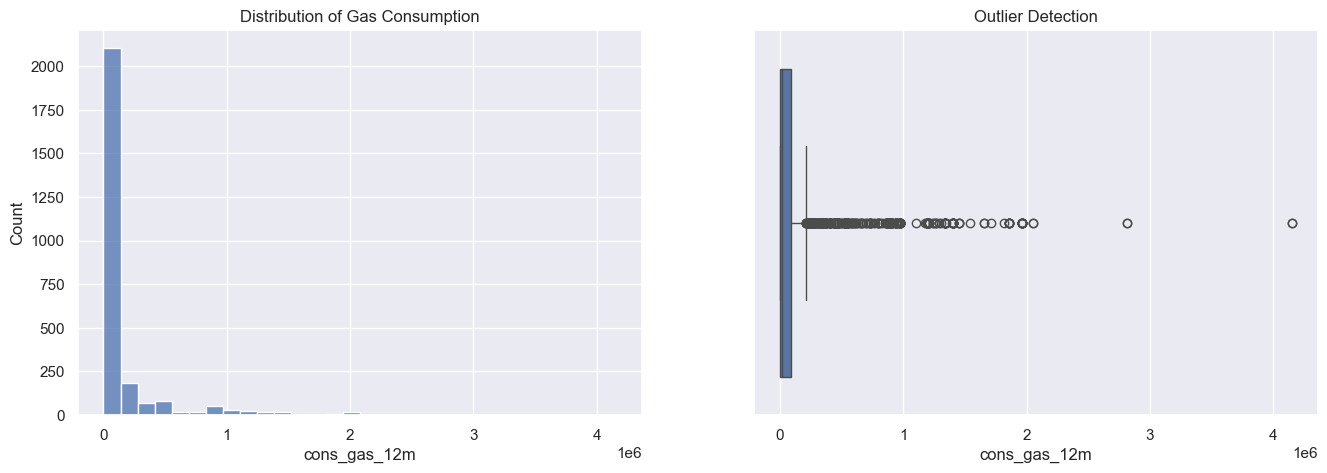

Number of outliers: 422
percentage of outliers: 15.918521312712183


In [20]:
#Outlier Detection For Gas Consumption

fig, axes = plt.subplots(1,2, figsize=(16,5))

# Histogram Visualization 
sns.histplot(gas_clients["cons_gas_12m"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Gas Consumption")

# Boxplot Visualization
sns.boxplot(x=gas_clients["cons_gas_12m"], ax=axes[1])
axes[1].set_title("Outlier Detection")

plt.show()

# Calculate IQR
Q1 = gas_clients["cons_gas_12m"].quantile(0.25)
Q3 = gas_clients["cons_gas_12m"].quantile(0.75)

IQR = Q3 - Q1

min = Q1 - 1.5 * IQR
max = Q3 + 1.5 * IQR

outliers = gas_clients[
    (gas_clients["cons_gas_12m"] < min) |
    (gas_clients["cons_gas_12m"] > max)
]

#No of outliers
print("Number of outliers:", len(outliers))

#Percentage of outliers
print("percentage of outliers:", (len(outliers)/len(gas_clients))*100)

The distribution of gas consumption (`cons_gas_12m`) was analyzed to identify potential outliers.

- The distribution is highly right-skewed, with most customers having very low consumption and a small subset exhibiting extremely high usage.
- This skewness is further amplified by the fact that **not all customers use gas services**, resulting in a concentration of low or zero values.
- Boxplot analysis revealed a substantial number of points beyond the upper whisker, indicating the presence of significant outliers.
- Total outliers detected: **422**
- Percentage of outliers: **~15.9%**
- These outliers can disproportionately influence statistical summaries and machine learning models.
- The relatively high proportion of outliers suggests that these observations likely represent **distinct customer segments**, such as high-usage households or commercial/industrial consumers.

> **Given their potential business significance, outliers should not be removed blindly.** Instead, appropriate techniques such as log transformation or customer segmentation should be applied to better capture underlying consumption patterns.

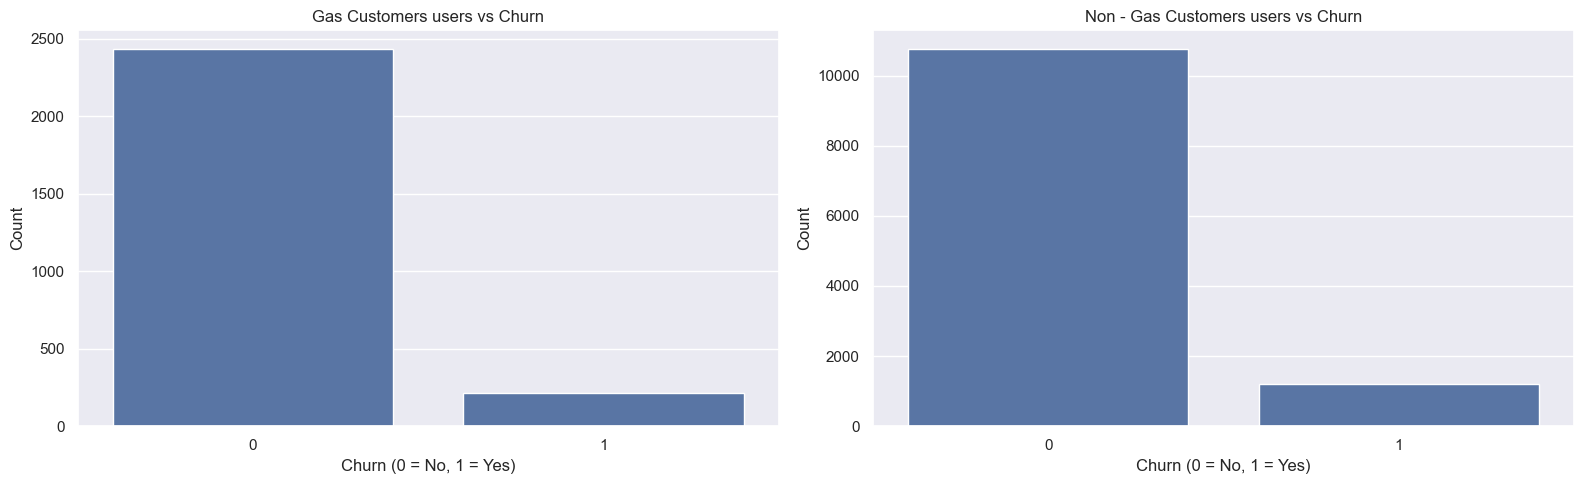

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Gas Customers v/s churn
sns.countplot(x="churn", data=gas_clients, ax=axes[0])
axes[0].set_title("Gas Customers users vs Churn")
axes[0].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[0].set_ylabel("Count")

# Non Gas Customers v/s churn
sns.countplot(x="churn", data=non_gas_clients, ax=axes[1])
axes[1].set_title("Non - Gas Customers users vs Churn")
axes[1].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

Gas subscription behavior was analyzed by segmenting customers into gas users (multi-service) and non-gas users (single-service) to understand its relationship with churn.
- Both segments exhibited a class imbalance, with a majority of customers not churning
- Non-gas customers constituted a larger share of the customer base, contributing to a higher absolute number of churn cases
- Gas customers showed stronger retention patterns, indicating higher customer stickiness
- In contrast, non-gas customers demonstrated a relatively higher tendency to churn, likely due to lower service dependency

> **While gas subscription appears to have a protective effect against churn, it is not a definitive standalone predictor**. This suggests that service bundling plays a role in retention, but churn behavior is also influenced by other factors such as pricing sensitivity, contract duration, and overall customer engagement.

## **Customer Engagement v/s Churn**

In [23]:
#No .of products
client.nb_prod_act.value_counts()

nb_prod_act
1     11431
2      2445
3       523
4       150
5        31
9        11
6         8
8         4
10        2
32        1
Name: count, dtype: int64

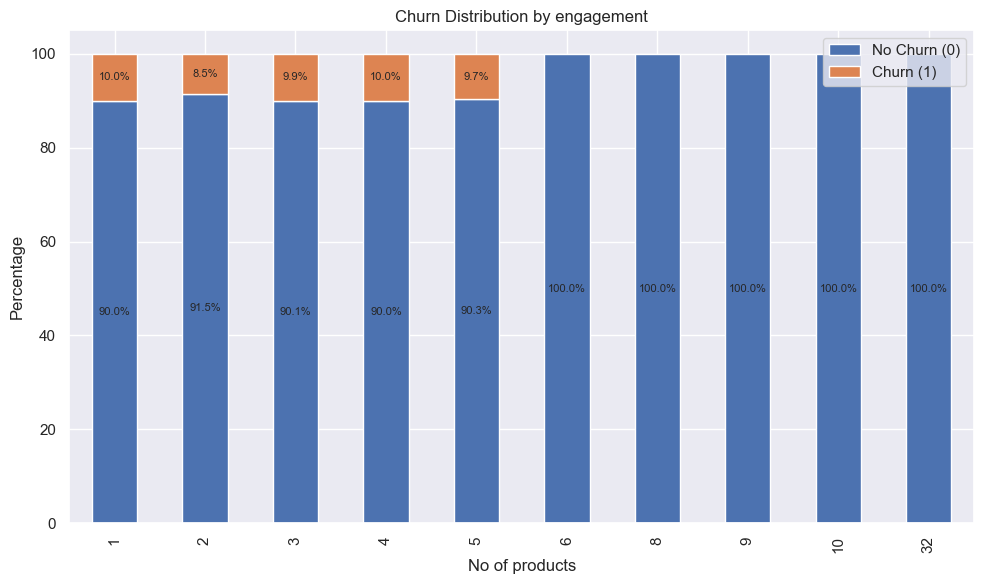

In [24]:
# Create aggregation table
engagement = (client.groupby(['nb_prod_act', 'churn']).size().unstack(fill_value=0))

# Total customers per channel ( total = churn + no churn )
engagement_count = engagement.sum(axis=1)

# Counts to percentage( nochurn% = nochurn/total )
engagement_churn = engagement.div(engagement_count, axis=0) * 100

# Plot engagement
ax = engagement_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6))

# Annotate each segment
for i, (index, row) in enumerate(engagement_churn.iterrows()):
    cumulative = 0
    for val in row:
        if val > 0:
            ax.text(
                i,
                cumulative + val / 2, f"{val:.1f}%",
                ha='center', va='center', fontsize = 8)
            cumulative += val
                
plt.title("Churn Distribution by engagement")
plt.xlabel("No of products")
plt.ylabel("Percentage")
plt.legend(["No Churn (0)", "Churn (1)"])
plt.tight_layout()
plt.show()

- Customers with 1 to 5 products show relatively similar churn rates, ranging approximately between 8% and 10%.
- There is no strong decreasing trend in churn as the number of products increases within this range.
- For customers with more than 5 products, churn appears to drop to 0%.
- The segments with 6+ products have very few observations, which may lead to unreliable or misleading conclusions.
- The apparent 0% churn in these groups is likely due to low sample size rather than a true business pattern.

**Insights:**
- The number of products alone does not show a strong or consistent relationship with churn in its raw form.
- High product count segments require careful handling due to data sparsity.

**Conclusion:**
> While product count is an important behavioral feature, its raw form introduces noise and unreliable patterns in higher ranges.  
> Grouping customers into broader categories (e.g., 1, 2, 3, 4, 5+) provides more stable and meaningful insights.

**Next Step:**
- Create a grouped feature (`prod_group`) to reduce noise and improve interpretability for modeling.

## **Tenure v/s Churn**

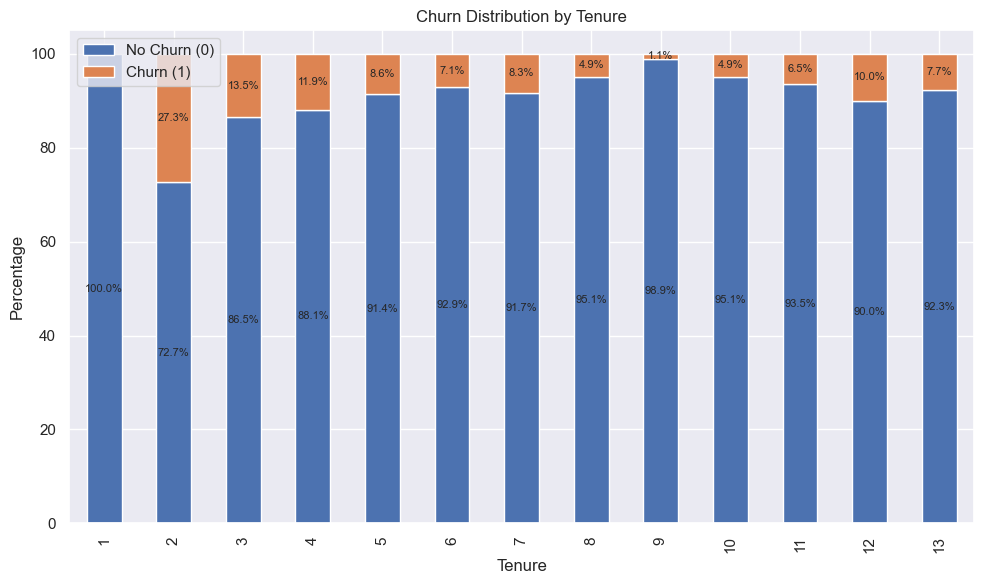

In [26]:
# Create aggregation table
tenure = (client.groupby(['num_years_antig', 'churn']).size().unstack(fill_value=0))

# Total customers per channel ( total = churn + no churn )
tenure_count = tenure.sum(axis=1)

# Counts to percentage( nochurn% = nochurn/total )
tenure_churn = tenure.div(tenure_count, axis=0) * 100

# Plot tenure
ax = tenure_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6))

# Annotate each segment
for i, (index, row) in enumerate(tenure_churn.iterrows()):
    cumulative = 0
    for val in row:
        if val > 0:
            ax.text(
                i,
                cumulative + val / 2, f"{val:.1f}%",
                ha='center', va='center', fontsize = 8)
            cumulative += val
                
plt.title("Churn Distribution by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Percentage")
plt.legend(["No Churn (0)", "Churn (1)"])
plt.tight_layout()
plt.show()


- Customer tenure has a strong inverse relationship with churn — newer customers are significantly more likely to leave than long-term customers.

> **Customer tenure is one of the strongest predictors of churn**. Customers are most vulnerable in their early lifecycle, while long-term customers exhibit strong retention behavior.

## **Profitability v/s Churn**

In [27]:
client[["margin_gross_pow_ele",
    "margin_net_pow_ele",
    "net_margin"]].corr()

,margin_gross_pow_ele,margin_net_pow_ele,net_margin
margin_gross_pow_ele,1.000000,0.999914,0.031814
margin_net_pow_ele,0.999914,1.000000,0.031639
net_margin,0.031814,0.031639,1.000000


## **Churn Count per month**

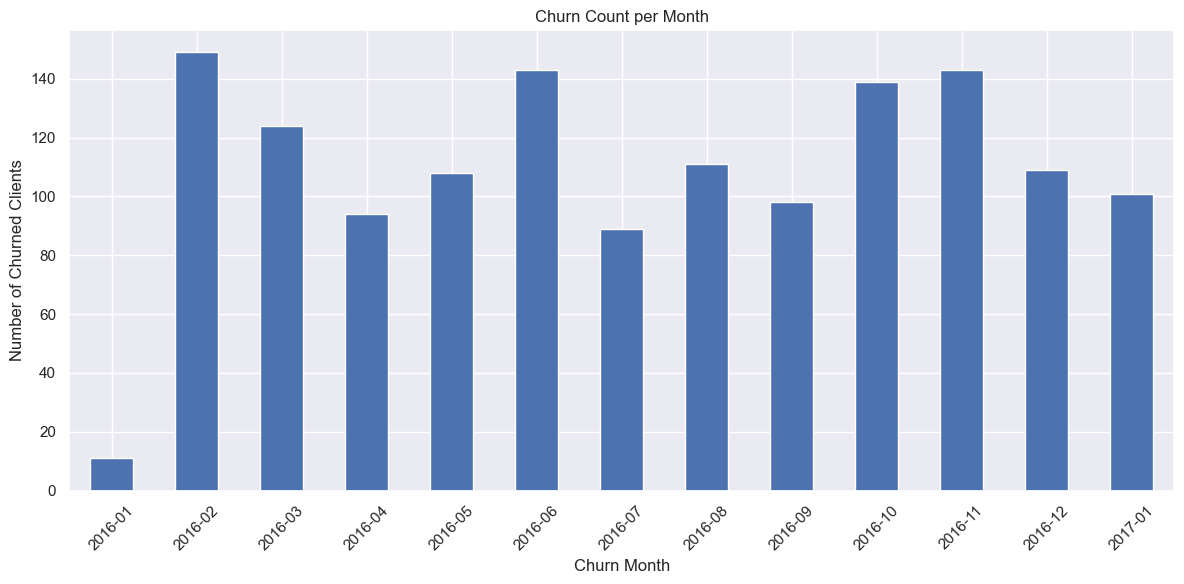

In [28]:
# Convert to datetime
client["date_end"] = pd.to_datetime(client["date_end"], errors="coerce")

# Filter churn customers
clients_churned = client[client["churn"] == 1].copy()

# Extract churn month from 'date_end'
clients_churned["churn_month"] = clients_churned["date_end"].dt.to_period("M")

# Count churns per month
churn_per_month = clients_churned["churn_month"].value_counts().sort_index()

# Plot churn count per month
churn_per_month.plot(kind='bar', figsize=(12,6), title='Churn Count per Month')
plt.xlabel("Churn Month")
plt.ylabel("Number of Churned Clients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Churn does not follow a strong seasonal trend but shows moderate fluctuations across months.**

# **Price Dataset Exploration**

## Price Dataset Features

| Feature | Description |
|--------|-------------|
| id | client company identifier |
| price_date | reference date |
| price_off_peak_var | price of energy for the 1st period (off peak) |
| price_peak_var | price of energy for the 2nd period (peak) |
| price_mid_peak_var | price of energy for the 3rd period (mid peak) |
| price_off_peak_fix | price of power for the 1st period (off peak) |
| price_peak_fix | price of power for the 1st period (off peak) |
| price_mid_peak_fix | price of power for the 3rd period (mid peak)

In [31]:
price.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


## **Data Quality Assessment**

In [33]:
price.shape

#Data Type Consistency Check
price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


In [56]:
# Convert all columns to numeric
price_cols = [
    'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']

price[price_cols] = price[price_cols].apply(pd.to_numeric, errors='coerce')

In [34]:
#missing values check
price.isnull().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

In [35]:
# Duplicate Records check
client.duplicated().sum()

0

In [36]:
price.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


- Off-peak variable price highest: mean = 0.141
- Peak & mid-peak variable prices lower: 0.054, 0.030
- Fixed prices significantly higher scale:
- Off-peak: 43.33, Peak: 10.62, Mid-peak: 6.41
- High number of zeros in peak & mid-peak (var + fix)
- Median = 0 for several features → strong skewness
- Highly skewed distributions (especially peak/mid-peak)
- High variance in peak pricing → volatility
- Uneven spread across quartiles → non-uniform pricing behavior
- Unexpected: off-peak > peak pricing (on average)

## **Time-Based Analysis**

<Axes: xlabel='price_date'>

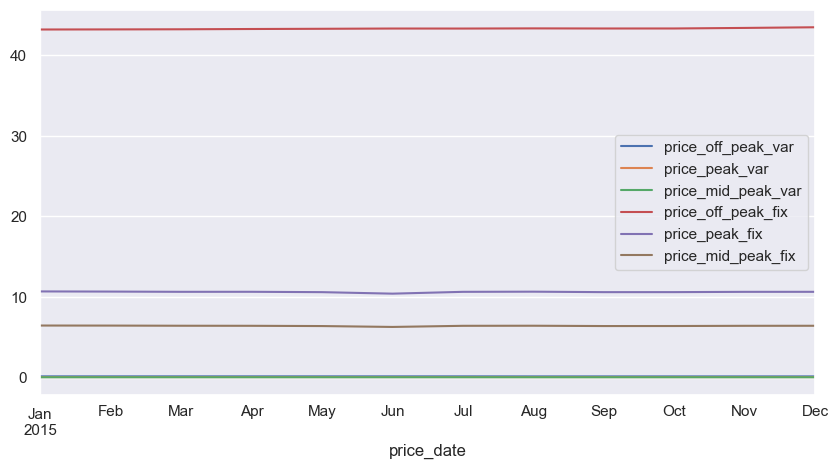

In [50]:
#Convert to datetime
price['price_date'] = pd.to_datetime(price['price_date'])

price_date = price.groupby('price_date').mean(numeric_only=True)
price_date.plot(figsize=(10,5))

- Variable prices show very low variance across time, with off-peak (~0.14) consistently highest, followed by peak (~0.055) and mid-peak (~0.03)
- Slight dip observed around mid-year (July–August) in off-peak and peak variable prices, but overall trend remains stable

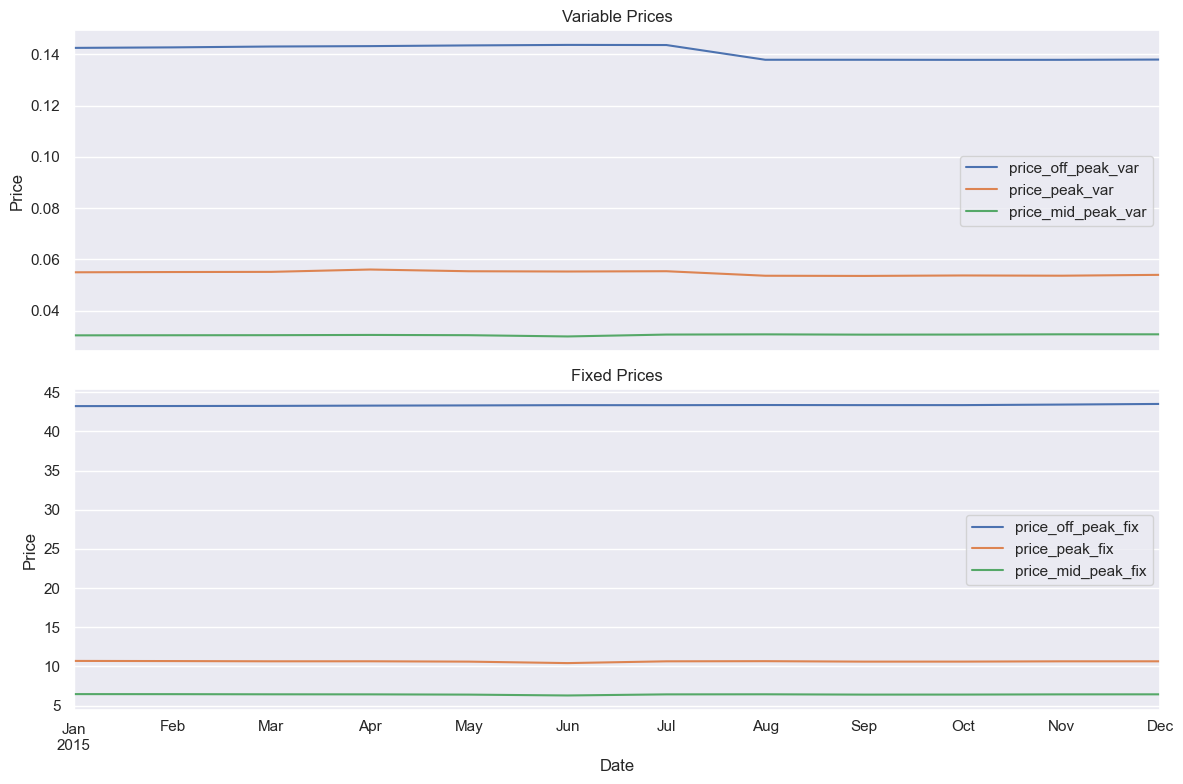

In [61]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Variable prices plot
price.groupby('price_date')[price_cols[:3]].mean().plot(
    ax=axes[0],
    title='Variable Prices'
)
axes[0].set_ylabel('Price')
axes[0].grid(True)

# Fixed prices plot
price.groupby('price_date')[price_cols[3:]].mean().plot(
    ax=axes[1],
    title='Fixed Prices'
)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price')
axes[1].grid(True)

plt.tight_layout()
plt.show()

- **Variable prices show very low variance across time**, with off-peak (~0.14) consistently highest, followed by peak (~0.055) and mid-peak (~0.03)
- Slight dip observed around mid-year (July–August) in off-peak and peak variable prices, but overall trend remains stable
- **Fixed prices dominate the pricing structure**, with off-peak fixed (~43–44) significantly higher than peak (~10–11) and mid-peak (~6–7)
- **Fixed pricing is highly stable throughout the year**, indicating minimal volatility and likely regulated or contract-based pricing
- No strong seasonality or trend patterns observed in either variable or fixed prices
- **Clear price hierarchy across periods**: off-peak > peak > mid-peak (consistent in both variable and fixed components)
- Narrow fluctuations suggest predictable pricing behavior, suitable for forecasting models

## **Distribution Analysis**

array([[<Axes: title={'center': 'price_off_peak_var'}>,
        <Axes: title={'center': 'price_peak_var'}>],
       [<Axes: title={'center': 'price_mid_peak_var'}>, <Axes: >]],
      dtype=object)

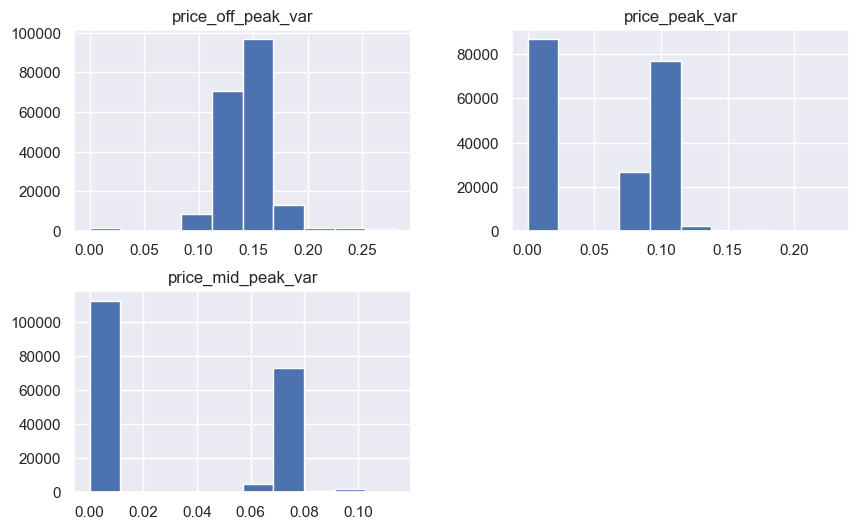

In [ ]:
price_var = ['price_off_peak_var','price_peak_var','price_mid_peak_var']
price[price_var].hist(figsize=(10,6))

- **price_off_peak_var shows a near-normal distribution** centered around ~0.13–0.16, indicating consistent pricing with low variability
- **price_peak_var is bimodal and zero-inflated**, with a large spike at 0 and another cluster around ~0.09–0.11, suggesting mixed customer pricing plans or missing/inactive tariffs
- **price_mid_peak_var is heavily zero-dominated**, with most values at 0 and a smaller cluster around ~0.06–0.08, indicating limited usage or availability of this tariff
- Strong presence of zero values introduces **high skewness in peak and mid-peak distributions**
- **Off-peak pricing appears stable** and widely applied, while **peak and mid-peak pricing are inconsistent** across customers
- **Distribution patterns confirm heterogeneous pricing structure**, likely due to different contract types or customer segmentation

array([[<Axes: title={'center': 'price_off_peak_fix'}>,
        <Axes: title={'center': 'price_peak_fix'}>],
       [<Axes: title={'center': 'price_mid_peak_fix'}>, <Axes: >]],
      dtype=object)

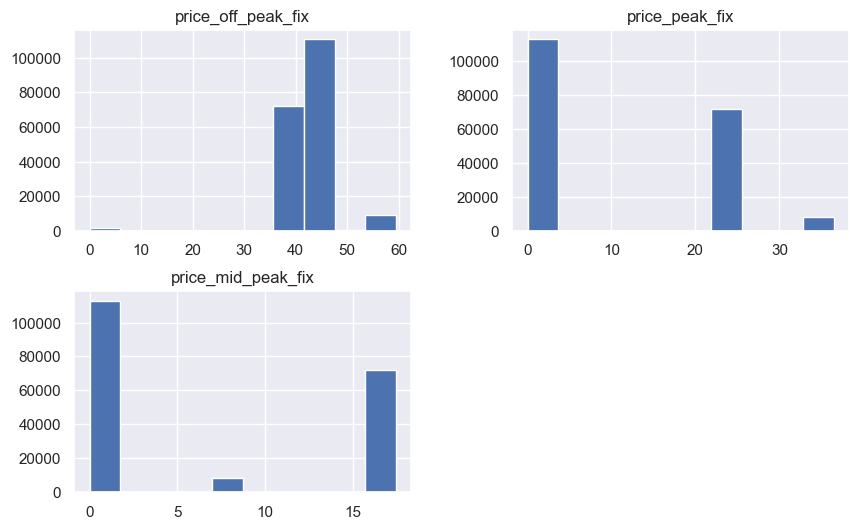

In [62]:
price_fix = ['price_off_peak_fix','price_peak_fix','price_mid_peak_fix']
price[price_fix].hist(figsize=(10,6))

- **price_off_peak_fix shows a tight concentration around 40–45**, indicating stable and standardized pricing across most customers
- Minor spread toward higher values (~55–60) suggests limited premium or outlier pricing tiers
- **price_peak_fix is bimodal**, with a large spike at 0 and another around 20–25, indicating many customers either do not have peak pricing or are on different tariff plans
- **price_mid_peak_fix is also zero-inflated**, with most values at 0 and a secondary cluster around 15–17, reinforcing selective usage of this pricing component
- Off-peak fixed pricing appears universally applied, while peak and mid-peak are conditional or optional components
- Distributions are highly skewed for peak and mid-peak, but relatively stable and normal-like for off-peak
- Clear segmentation suggests different pricing plans or contract types across customers

<Axes: >

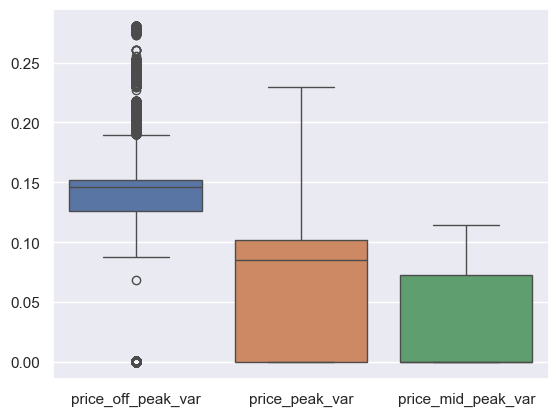

In [46]:
sns.boxplot(data=price[price_dist])

- **price_off_peak_var shows a tight distribution** with median around ~0.14, indicating stable pricing across most customers
- Presence of multiple high-value outliers (~0.20–0.28) suggests a small segment of customers on premium or anomalous pricing plans
- A few extreme low values (including 0) indicate potential missing data or inactive tariffs
- **price_peak_var has a wide spread with median ~0.085**, but **lower quartile at 0, confirming strong zero-inflation**
- Large variability in peak pricing indicates inconsistent pricing structures across customers
- price_mid_peak_var is heavily concentrated at 0, with limited spread up to ~0.11, showing this tariff is not widely applied
- **Interquartile range (IQR) for mid-peak is small**, reinforcing low variability but sparse usage

**Zero-heavy distributions suggest need for:**

- Binary feature engineering (has_peak_var, has_mid_peak_var)
- Separate treatment of zero vs non-zero values

## **Correlation Analysis**

<Axes: >

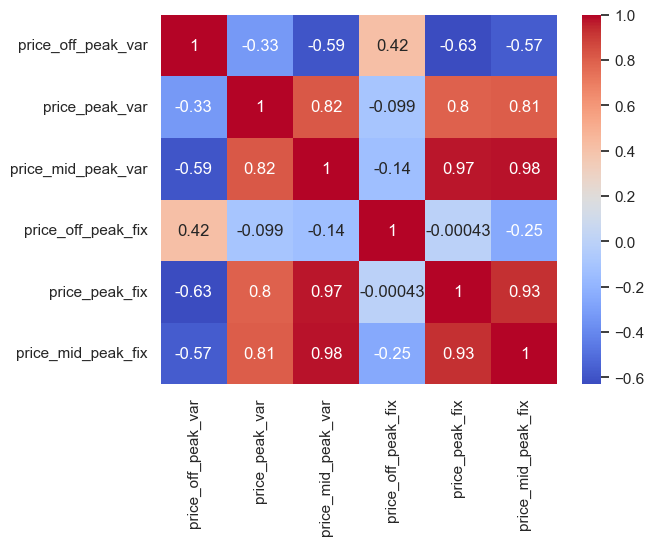

In [48]:
corr = price.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

- Presence of **multicollinearity among peak and mid-peak features**: Indicates closely linked pricing structure across peak periods
- Very high correlation between price_peak_fix ↔ price_mid_peak_fix (0.93)
- **Off-peak variable price is negatively correlated with most other features**
- **Weak or near-zero correlation between off-peak fixed and peak fixed**: Suggests independent pricing mechanisms for off-peak fixed charges
- Moderate positive correlation between price_off_peak_var ↔ price_off_peak_fix 

**Next Steps:**

Clear clustering of features into two groups:
- Peak/Mid-peak (highly correlated group)
- Off-peak (relatively independent behavior)

## **Fixed vs Variable Price Analysis**

<Axes: xlabel='price_off_peak_var', ylabel='price_off_peak_fix'>

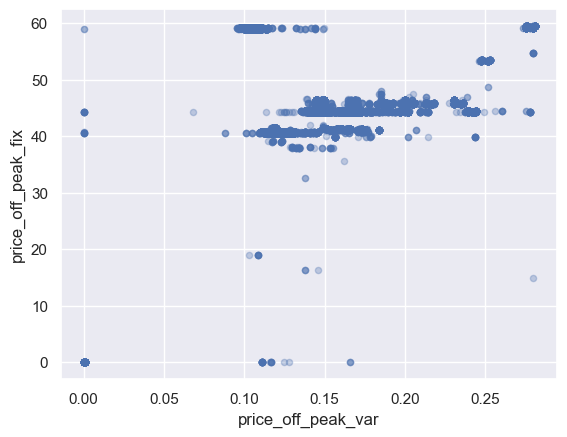

In [67]:
price.plot.scatter(x='price_off_peak_var', y='price_off_peak_fix', alpha=0.3)

- Scatter plot shows a moderate positive relationship between price_off_peak_var and price_off_peak_fix
- Majority of data points cluster around: Variable price: 0.12–0.20 & Fixed price: 40–46 → indicates standard pricing range
- Presence of horizontal bands (~40–45 and ~58–60) suggests tiered or grouped pricing plans
- Outliers observed: Very low fixed prices (~0–20) & High fixed prices (~55–60) → possible premium plans
- Weak spread in X but wider variation in Y indicates Fixed pricing varies more than variable pricing

Overall relationship is not strongly linear, suggesting:
- Fixed and variable prices are partially independent
- Clustering pattern confirms customer segmentation in pricing models